<div style="background: linear-gradient(to right, #6a11cb, #2575fc); padding: 20px; border-radius: 12px; text-align: center; box-shadow: 0 4px 6px rgba(0,0,0,0.1);">
  <h1 style="color: #fff; margin: 0; font-size: clamp(1.8rem, 3.5vw, 2.6rem); font-weight: 800;">
    GAICo: Evaluating AI-Generated Images
  </h1>
  <p style="color: #e8e8e8; margin-top: 10px; font-style: italic; font-size: clamp(1rem, 2.2vw, 1.2rem);">
    Why specialized image metrics matter
  </p>
</div>
<br>

<a href="https://colab.research.google.com/github/ai4society/GenAIResultsComparator/blob/main/examples/example-image.ipynb" target="_blank" rel="noopener">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Google Colab">
</a>

This notebook shows how **GAICo** assesses the quality of AI-generated images compared to a reference image.
We will compare two cases:  
- **Road signs**, where every letter and symbol matters.  
- **An interracial basketball team**, where skin tone, facial features, and team composition need to be preserved.

**The following metrics were chosen because they capture complementary aspects of visual quality:**
  - `ImageSSIM`: SSIM measures structural and luminance similarity, which aligns closely with human perception. 
  - `ImageAverageHash`: Average Hash encodes the overall composition into a compact fingerprint. It is robust to small pixel changes while still detecting layout differences.
  - `ImageHistogramMatch`: Histogram Match compares color distribution, and is important for tasks where hues, saturation, or tonal balance matter (e.g., skin tones, brand colors). 


Together, these metrics provide a balanced evaluation of generated images in comparison to a reference image.

### Setup for Google Colab

If you are running this notebook in Google Colab, uncomment and run the following cell to install the `gaico` package with the necessary audio dependencies.

In [ ]:
# !pip install 'gaico[image]' -q

### Environment Setup & Imports

The cell below adjusts `sys.path` to find the `gaico` module if you are running this notebook locally from the `examples/` directory without having installed the package.

In [1]:
import os
import sys
# Adjust sys.path to find the gaico module if run from examples directory
notebook_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(notebook_dir, os.pardir))

if project_root not in sys.path:
    sys.path.insert(0, project_root)
    print(f"Added project root to sys.path: {project_root}")

Added project root to sys.path: /Users/kausiklakkaraju/Documents/researchPhd/projects/work/genai-metrics/GenAIResultsComparator


In [14]:
import pandas as pd
from pathlib import Path
from IPython.display import Image, display
from PIL import Image
# Import the Experiment class for streamlined comparison
from gaico import Experiment

### Data Loading and Provenance

The reference (original) image files used in this example were obtained from Google. A small vertical line is added to the image to create a noisy variant, and other variants of the image were generated from two different models: ChatGPT 5, Gemini 2.5 Pro.

In [3]:

# Base path for images
image_dir = Path("data/images")

categories = ["Basketball Team", "Street Sign"]
variants = ["original", "GPT", "Gemini"]

folders = {
    "Basketball Team": "team",
    "Street Sign": "street-sign"
}

image_sets = {
    cat: {
        var: str(image_dir / folders[cat] / f"{folders[cat]}_{var.lower()}.png") 
        if var != "original" else str(image_dir / folders[cat] / f"{folders[cat]}.png")
        for var in variants
    }
    for cat in categories
}

reference_images = {cat: image_sets[cat]["original"] for cat in categories}

print("Reference Image Paths:")
for cat, ref_path in reference_images.items():
    print(f"- {cat}: {ref_path}")

print("\nImage Variants:")
for cat in categories:
    for var in variants:
        print(f"- {cat} ({var}): {image_sets[cat][var]}")


Reference Image Paths:
- Basketball Team: data/images/team/team.png
- Street Sign: data/images/street-sign/street-sign.png

Image Variants:
- Basketball Team (original): data/images/team/team.png
- Basketball Team (GPT): data/images/team/team_gpt.png
- Basketball Team (Gemini): data/images/team/team_gemini.png
- Street Sign (original): data/images/street-sign/street-sign.png
- Street Sign (GPT): data/images/street-sign/street-sign_gpt.png
- Street Sign (Gemini): data/images/street-sign/street-sign_gemini.png


## Case Study - 1: Basketball Team

### View the Images

Before computing the metrics, let us look at the reference image alongside the generated variants to get a visual sense of their differences.


Basketball Team — Reference Image (Original):


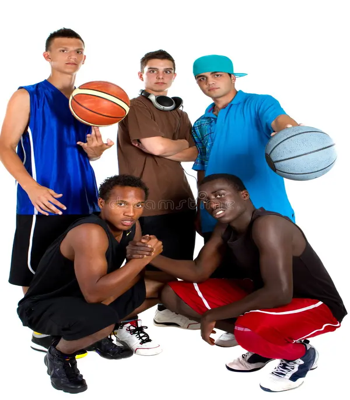


Basketball Team — GPT Variant:


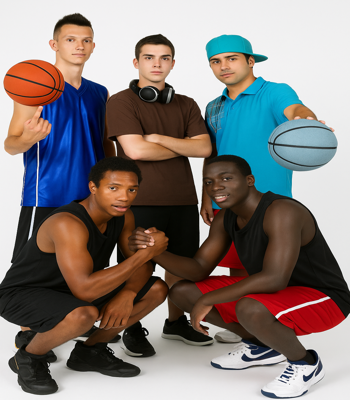


Basketball Team — Gemini Variant:


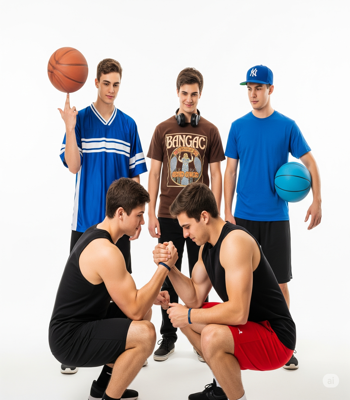

In [21]:
DISPLAY_SIZE = (350, 400) 

# Basketball Team
print("Basketball Team — Reference Image (Original):")
display(Image.open(image_sets["Basketball Team"]["original"]).resize(DISPLAY_SIZE))

print("\nBasketball Team — GPT Variant:")
display(Image.open(image_sets["Basketball Team"]["GPT"]).resize(DISPLAY_SIZE))

print("\nBasketball Team — Gemini Variant:")
display(Image.open(image_sets["Basketball Team"]["Gemini"]).resize(DISPLAY_SIZE))

## Visual Observations
**GPT Variant:** Skin tones of the players slightly washed out. Some faces lose detail. Their uniforms keep the correct color.

**Gemini Variant:** Skin tones warmer but inconsistent. Minor distortions in facial structure of the players. Their uniform colors and design changed.

### Running the Experiment

Now, we will use the `Experiment` class to compare the generated image files against the reference using our selected metrics.

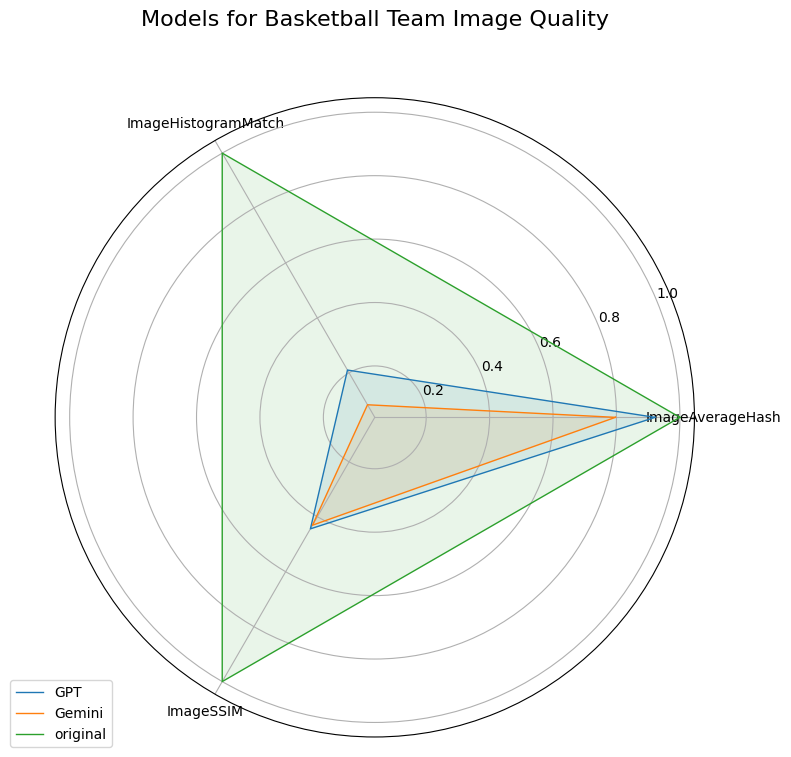

CSV report generated at: data/images/results/basketball_team_image_evaluation_results.csv

Results saved to: data/images/results/basketball_team_image_evaluation_results.csv
metric_name  ImageAverageHash  ImageHistogramMatch  ImageSSIM
model_name                                                   
GPT                    0.9219               0.2101     0.4439
Gemini                 0.7969               0.0837     0.4307
original               1.0000               1.0000     1.0000


In [5]:
team_images = {name: Image.open(path) for name, path in image_sets["Basketball Team"].items()}
team_reference = Image.open(reference_images["Basketball Team"])

team_exp = Experiment(
    llm_responses=team_images,
    reference_answer=team_reference
)

output_dir = Path("data/images/results")
output_dir.mkdir(parents=True, exist_ok=True)
csv_path = output_dir / "basketball_team_image_evaluation_results.csv"

results_df = team_exp.compare(
    metrics=["ImageSSIM", "ImageAverageHash", "ImageHistogramMatch"],
    plot=True,
    output_csv_path=csv_path,
    plot_title_suffix="for Basketball Team Image Quality",
)

print(f"\nResults saved to: {csv_path}")
with pd.option_context("display.precision", 4):
    print(results_df.pivot(index="model_name", columns="metric_name", values="score"))


### Analysis of Results: Basketball Team

`ImageAverageHash` ranks GPT highest (0.922) for preserving scene layout, while Gemini’s lower score (0.797) indicates a good amount of structural changes.  
`ImageHistogramMatch` and `ImageSSIM` drop sharply for both models due to watermark removal (the original image had one), skin tone shifts (for Gemini), and clothing color changes, factors that alter color distributions and local textures. GPT maintains the interracial composition, while Gemini alters demographics.



Street Sign — Reference Image (Original):


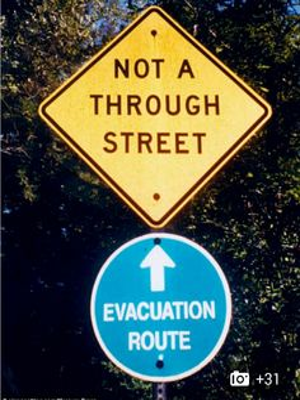


Street Sign — GPT Variant:


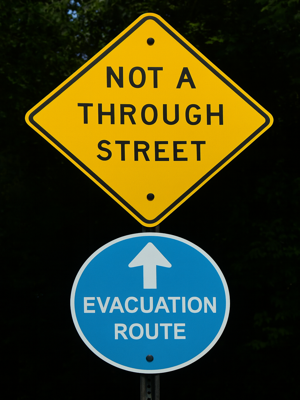


Street Sign — Gemini Variant:


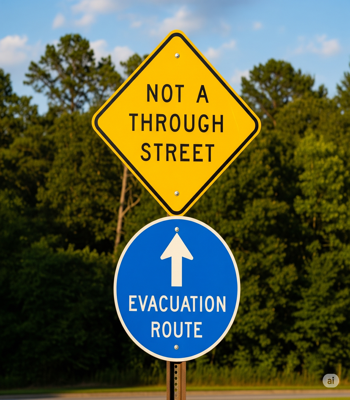

In [27]:
DISPLAY_SIZE = (350, 400) 

# Street Sign - Reference
print("\nStreet Sign — Reference Image (Original):")
display(Image.open(image_sets["Street Sign"]["original"]).resize((300,400)))

# Street Sign - GPT Variant
print("\nStreet Sign — GPT Variant:")
display(Image.open(image_sets["Street Sign"]["GPT"]).resize((300,400)))

# Street Sign — Gemini Variant
print("\nStreet Sign — Gemini Variant:")
display(Image.open(image_sets["Street Sign"]["Gemini"]).resize(DISPLAY_SIZE))


## Visual Observations
**GPT Variant:** Background has become more darker. 


**Gemini Variant:** Sharper edges than GPT but background is completely different from the reference image.

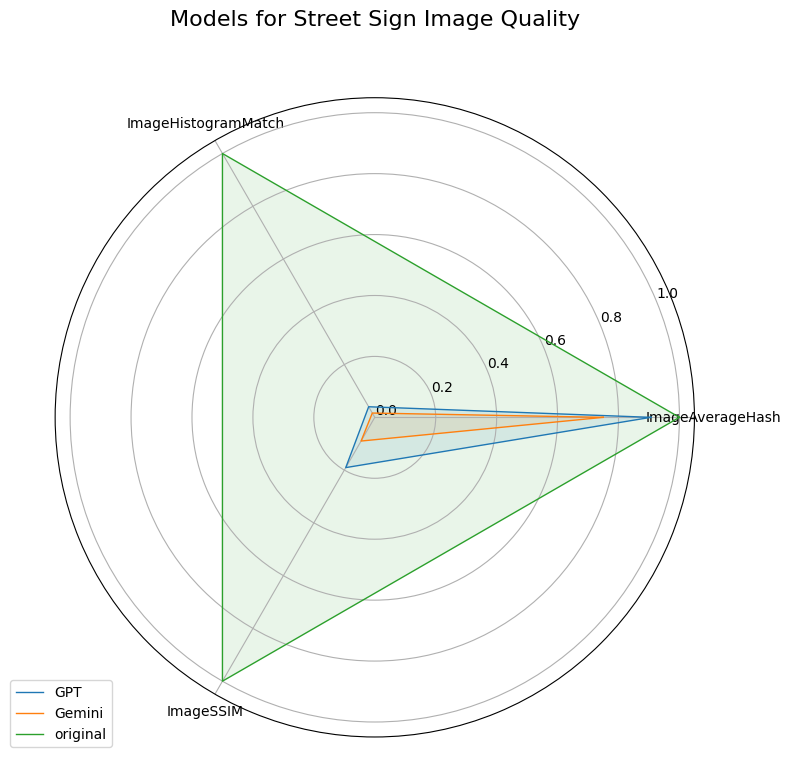

CSV report generated at: data/images/results/street_signs_image_evaluation_results.csv

Results saved to: data/images/results/street_signs_image_evaluation_results.csv
metric_name  ImageAverageHash  ImageHistogramMatch  ImageSSIM
model_name                                                   
GPT                    0.9062               0.0402     0.1905
Gemini                 0.7500               0.0163     0.0898
original               1.0000               1.0000     1.0000


In [10]:
team_images = {name: Image.open(path) for name, path in image_sets["Street Sign"].items()}
team_reference = Image.open(reference_images["Street Sign"])

team_exp = Experiment(
    llm_responses=team_images,
    reference_answer=team_reference
)

output_dir = Path("data/images/results")
output_dir.mkdir(parents=True, exist_ok=True)
csv_path = output_dir / "street_signs_image_evaluation_results.csv"

results_df = team_exp.compare(
    metrics=["ImageSSIM", "ImageAverageHash", "ImageHistogramMatch"],
    plot=True,
    output_csv_path=csv_path,
    plot_title_suffix="for Street Sign Image Quality",
)

print(f"\nResults saved to: {csv_path}")
with pd.option_context("display.precision", 4):
    print(results_df.pivot(index="model_name", columns="metric_name", values="score"))


### Analysis of Results: Street Signs

`ImageAverageHash` scores (0.9062 GPT, 0.7500 Gemini) show GPT’s overall composition is closer to the reference.
Very low `ImageHistogramMatch` and `ImageSSIM` values for both models (≤0.04 and ≤0.19) indicate significant palette and texture changes, likely affecting the background (darker background with Gemini, and more greenery with GPT).

## Conclusion

Using structure-, layout-, and color-based metrics together provides a balanced view of how each generated image aligns with its reference. `ImageAverageHash` showed differences in scene composition, while `ImageHistogramMatch` and `ImageSSIM` showed changes in color balance and texture. In practice, this showed that the GPT and Gemini outputs, though similar at first glance, differed in background on road signs (though both Gemini and ChatGPT generated the correct road sign text) and in skin tone and players' uniform consistency for the basketball images.
